# Download from Comet

Set the config, put asset filenames or asset IDs in `ASSETS`, and put metric names in `METRICS`. Files are saved into `comet_downloads/RUN_NAME/`.

In [1]:
import os
from itertools import cycle
from pathlib import Path

WORKSPACE = os.environ.get("COMET_WORKSPACE", "maurice-filo")
PROJECT = os.environ.get("COMET_PROJECT_NAME", "Habituation_hallmarks_custom")
# PROJECT = os.environ.get("COMET_PROJECT_NAME", "doseresponse-quadratic-task")
# PROJECT = os.environ.get("COMET_PROJECT_NAME", "doseresponse-sqrt-task")
EXPERIMENT_KEY = os.environ.get("COMET_EXPERIMENT_KEY", "0f5ad5c016a54ca494e7458ea676738e")
OUTPUT_DIR = Path("comet_downloads")
# RUN_NAME = "run_Quad_MA_8S_18R-11_Exp_2026-07-12"
# RUN_NAME = "run_Hab_MA_3S_8R-9_Exp_2026-07-23"
RUN_NAME = "run_Hab_CMM_4S_8R-1_Exp_2026-07-24"
# RUN_NAME = "run_sqrt_MA_3S_4R-1_Exp_2026-06-29"
RUN_DIR = OUTPUT_DIR / RUN_NAME

ASSETS = []  # exact filenames or asset IDs
LOSS_METRICS = ["Loss: Batch Best", "Loss: Top-127 Average", "Loss: Top-127 Worst"]
# LOSS_METRICS = ["Loss: Batch Best", "Loss: Top-64 Average", "Loss: Top-64 Worst"]
ENTROPY_METRIC = "Entropy: Batch"
TIMING_METRICS = [
    "Timing: Step",
    "Timing: Rewards",
    "Timing: Forward",
    "Timing: Backward",
    "Timing: Actuator",
    "Timing: Observe",
    "Timing: SIL",
    "Timing: Hall of Fame Update",
    "Timing: Render",
]
METRICS = LOSS_METRICS + [ENTROPY_METRIC] + TIMING_METRICS  # exact metric names

In [2]:
from comet_ml import API

api = API(api_key=os.environ["COMET_API_KEY"])

if EXPERIMENT_KEY:
    experiments = [api.get_experiment(WORKSPACE, PROJECT, EXPERIMENT_KEY)]
else:
    experiments = list(api.get_experiments(WORKSPACE, PROJECT))

len(experiments)

1

In [3]:
def safe_name(value):
    return "".join(c if c.isalnum() or c in "._-" else "_" for c in str(value)).strip("_")


def asset_id(asset):
    return asset.get("assetId") or asset.get("asset_id")


def asset_filename(asset):
    return asset.get("fileName") or asset.get("file_name") or asset.get("name") or asset_id(asset)


def selected_assets(experiment, selectors):
    all_assets = experiment.get_asset_list()
    selected = []
    seen = set()

    for selector in selectors:
        matches = [
            asset
            for asset in all_assets
            if selector in {asset_id(asset), asset_filename(asset)}
        ]
        if not matches:
            print(f"missing asset: {selector}")

        for asset in matches:
            ident = asset_id(asset)
            if ident not in seen:
                selected.append(asset)
                seen.add(ident)

    return selected


RUN_DIR.mkdir(parents=True, exist_ok=True)

if not ASSETS:
    print("No assets requested.")

for experiment in experiments:
    for asset in selected_assets(experiment, ASSETS):
        ident = asset_id(asset)
        filename = asset_filename(asset)
        path = RUN_DIR / safe_name(filename)

        response = experiment.get_asset(ident, return_type="response", stream=True)
        with path.open("wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

        print(path)

No assets requested.


In [4]:
import pandas as pd

RUN_DIR.mkdir(parents=True, exist_ok=True)

for experiment in experiments:
    for metric in METRICS:
        rows = experiment.get_metrics(metric)
        if not rows:
            continue

        path = RUN_DIR / f"{safe_name(metric)}.csv"
        pd.DataFrame(rows).to_csv(path, index=False)
        print(path)

comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Loss__Batch_Best.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Loss__Top-127_Average.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Loss__Top-127_Worst.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Entropy__Batch.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Step.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Rewards.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Forward.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Backward.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Actuator.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Observe.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__SIL.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Hall_of_Fame_Update.csv
comet_downloads/run_Hab_CMM_4S_8R-1_Exp_2026-07-24/Timing__Render.csv


## Plot Losses

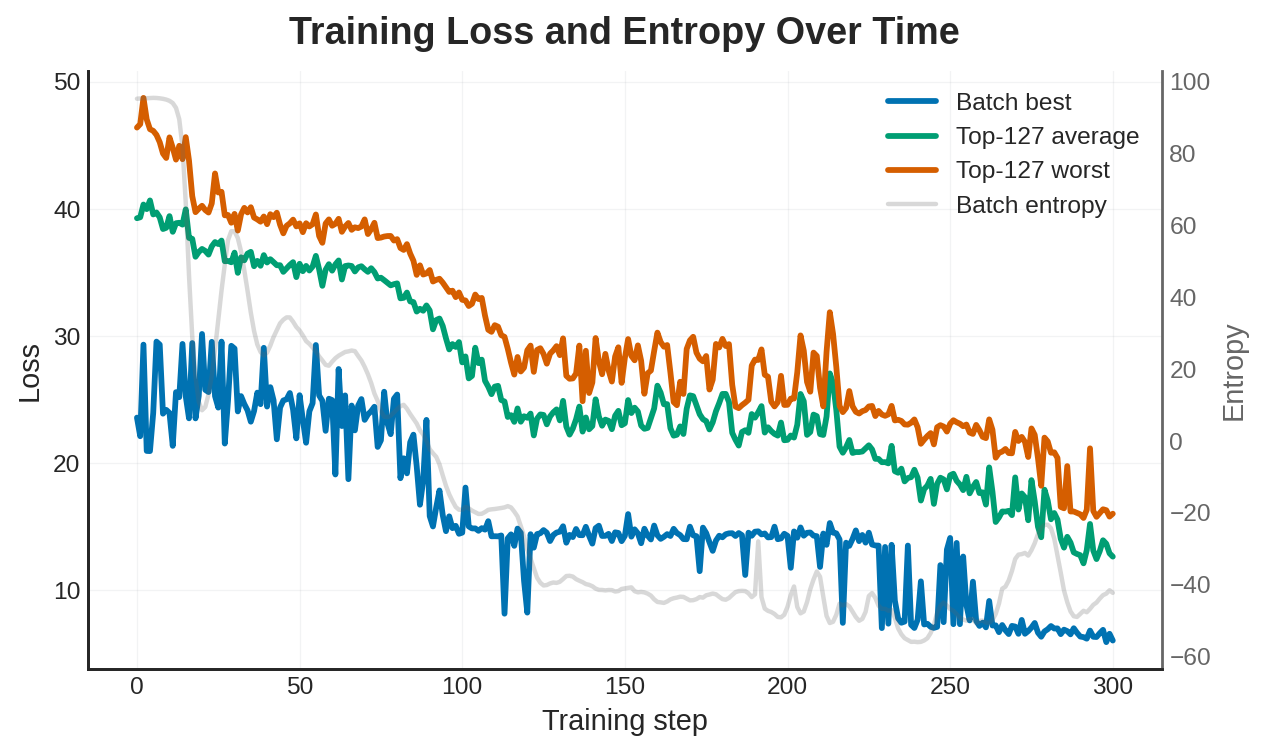

In [5]:
from itertools import cycle
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

LOSS_METRICS = globals().get(
    "LOSS_METRICS",
    ["Loss: Batch Best", "Loss: Top-64 Average", "Loss: Top-64 Worst"],
)
ENTROPY_METRIC = globals().get("ENTROPY_METRIC", "Entropy: Batch")

labels = {
    "Loss: Batch Best": "Batch best",
    "Loss: Top-127 Average": "Top-127 average",
    "Loss: Top-127 Worst": "Top-127 worst",
    "Entropy: Batch": "Batch entropy",
}

colors = {
    "Loss: Batch Best": "#0072B2",
    "Loss: Top-127 Average": "#009E73",
    "Loss: Top-127 Worst": "#D55E00",
}

def safe_name(value):
    return "".join(c if c.isalnum() or c in "._-" else "_" for c in str(value)).strip("_")

plot_dir = RUN_DIR if "RUN_DIR" in globals() else Path("comet_downloads/run_Hab_MA_3S_8R-9_Exp_2026-07-23")

plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(8, 4.8), dpi=160)
entropy_ax = ax.twinx()
ax.set_axisbelow(True)
entropy_ax.grid(False)

for metric in LOSS_METRICS:
    path = plot_dir / f"{safe_name(metric)}.csv"
    df = pd.read_csv(path)

    value_col = "metricValue" if "metricValue" in df.columns else "value"
    df["step"] = pd.to_numeric(df["step"])
    df[value_col] = pd.to_numeric(df[value_col])
    df = df.sort_values("step")

    ax.plot(
        df["step"],
        df[value_col],
        label=labels[metric],
        color=colors[metric],
        linewidth=2.6,
    )

entropy_path = plot_dir / f"{safe_name(ENTROPY_METRIC)}.csv"
entropy_df = pd.read_csv(entropy_path)
entropy_value_col = "metricValue" if "metricValue" in entropy_df.columns else "value"
entropy_df["step"] = pd.to_numeric(entropy_df["step"])
entropy_df[entropy_value_col] = pd.to_numeric(entropy_df[entropy_value_col])
entropy_df = entropy_df.sort_values("step")

entropy_ax.plot(
    entropy_df["step"],
    entropy_df[entropy_value_col],
    label=labels[ENTROPY_METRIC],
    color="#666666",
    linewidth=2.0,
    alpha=0.25,
)

ax.set_title("Training Loss and Entropy Over Time", fontsize=17, weight="bold", pad=12)
ax.set_xlabel("Training step", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
entropy_ax.set_ylabel("Entropy", fontsize=13, color="#666666")

ax.tick_params(axis="both", labelsize=11)
entropy_ax.tick_params(axis="y", labelsize=11, colors="#666666")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
entropy_ax.spines["top"].set_visible(False)
entropy_ax.spines["right"].set_color("#666666")

handles, legend_labels = ax.get_legend_handles_labels()
entropy_handles, entropy_labels = entropy_ax.get_legend_handles_labels()
ax.legend(
    handles + entropy_handles,
    legend_labels + entropy_labels,
    frameon=False,
    fontsize=11,
    loc="upper right",
)

ax.grid(True, axis="both", color="#9AA0A6", linewidth=0.6, alpha=0.12)
entropy_ax.grid(False)
fig.tight_layout()
fig.savefig(plot_dir / "loss_metrics_presentation.pdf", bbox_inches="tight")
plt.show()

## Plot Timing Metrics

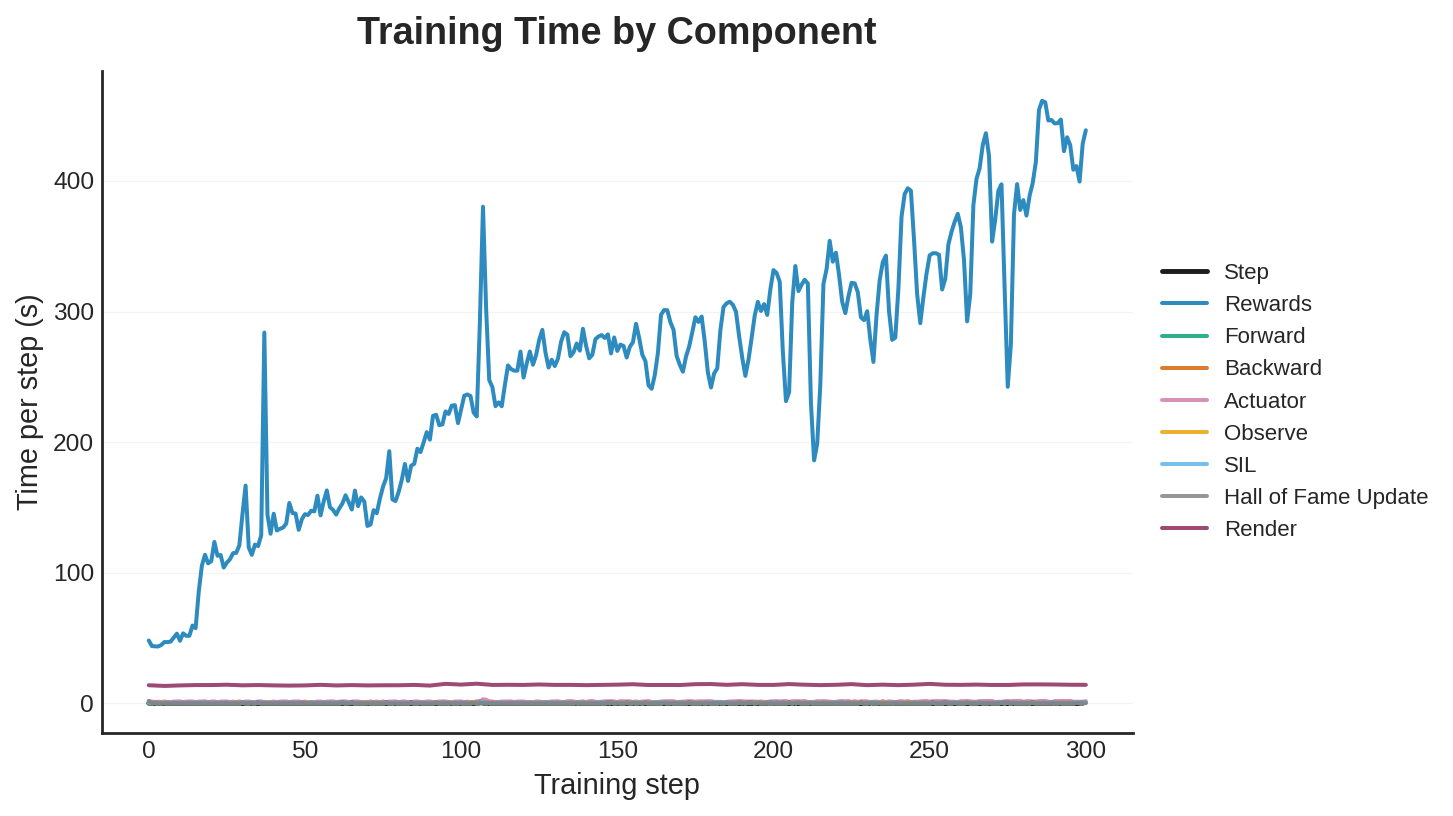

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def metric_value_column(df):
    return "metricValue" if "metricValue" in df.columns else "value"


def timing_label(path):
    return path.stem.removeprefix("Timing__").replace("_", " ")


plot_dir = RUN_DIR if "RUN_DIR" in globals() else Path("comet_downloads/run_Hab_MA_6S_12-1_Exp_2026-07-13")
timing_paths = sorted(plot_dir.glob("Timing__*.csv"))

if not timing_paths:
    candidate_dirs = sorted(
        {path.parent for path in Path("comet_downloads").rglob("Timing__*.csv")},
        key=lambda folder: max(path.stat().st_mtime for path in folder.glob("Timing__*.csv")),
        reverse=True,
    )
    if candidate_dirs:
        plot_dir = candidate_dirs[0]
        timing_paths = sorted(plot_dir.glob("Timing__*.csv"))
        print(f"Using timing files from {plot_dir}")

if not timing_paths:
    raise FileNotFoundError("No Timing__*.csv files found. Run the metric download cell with TIMING_METRICS included first.")

preferred_order = [
    "Timing__Step.csv",
    "Timing__Rewards.csv",
    "Timing__Forward.csv",
    "Timing__Backward.csv",
    "Timing__Actuator.csv",
    "Timing__Observe.csv",
    "Timing__SIL.csv",
    "Timing__Hall_of_Fame_Update.csv",
    "Timing__Render.csv",
]
order = {name: i for i, name in enumerate(preferred_order)}
timing_paths = sorted(timing_paths, key=lambda path: (order.get(path.name, len(order)), path.name))

plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(9.2, 5.2), dpi=160)

colors = [
    "#111111",
    "#0072B2",
    "#009E73",
    "#D55E00",
    "#CC79A7",
    "#E69F00",
    "#56B4E9",
    "#7F7F7F",
    "#882255",
]

for path, color in zip(timing_paths, cycle(colors)):
    df = pd.read_csv(path)
    value_col = metric_value_column(df)
    df["step"] = pd.to_numeric(df["step"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["step", value_col]).sort_values("step")

    ax.plot(
        df["step"],
        df[value_col],
        label=timing_label(path),
        color=color,
        linewidth=2.2 if path.name == "Timing__Step.csv" else 1.8,
        alpha=0.95 if path.name == "Timing__Step.csv" else 0.82,
    )

ax.set_title("Training Time by Component", fontsize=17, weight="bold", pad=12)
ax.set_xlabel("Training step", fontsize=13)
ax.set_ylabel("Time per step (s)", fontsize=13)

ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
ax.grid(True, axis="y", color="#9AA0A6", linewidth=0.6, alpha=0.12)
ax.grid(False, axis="x")

ax.legend(
    frameon=False,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
)

fig.tight_layout()
fig.savefig(plot_dir / "timing_metrics_presentation.pdf", bbox_inches="tight")
plt.show()